In [5]:
import pandas as pd
import numpy as np
from rich import columns

index1 = pd.MultiIndex.from_arrays([['a', 'a', 'a', 'b', 'b', 'b', 'c', 'c', 'c', 'd', 'd', 'd'], [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2]], names=['cloth', 'size'])
ser_obj = pd.Series(np.random.randn(12), index=index1)
print(ser_obj)
print('-' * 50)

df_obj = ser_obj.unstack(0)
print(df_obj)
print('-' * 50)

df_obj.loc[0, 'b'] = np.nan
print(df_obj)
print('-' * 50)

# axis=0：遍历各列的每行，求其最小值
print(df_obj.min(axis=0))

cloth  size
a      0      -0.081255
       1       0.646894
       2       0.763417
b      0       0.836096
       1      -0.695172
       2      -0.670366
c      0      -0.186121
       1      -1.509559
       2       1.248197
d      0       0.857351
       1      -0.362216
       2      -0.233517
dtype: float64
--------------------------------------------------
cloth         a         b         c         d
size                                         
0     -0.081255  0.836096 -0.186121  0.857351
1      0.646894 -0.695172 -1.509559 -0.362216
2      0.763417 -0.670366  1.248197 -0.233517
--------------------------------------------------
cloth         a         b         c         d
size                                         
0     -0.081255       NaN -0.186121  0.857351
1      0.646894 -0.695172 -1.509559 -0.362216
2      0.763417 -0.670366  1.248197 -0.233517
--------------------------------------------------
cloth
a   -0.081255
b   -0.695172
c   -1.509559
d   -0.362216
dtype: flo

In [6]:
df_obj

cloth,a,b,c,d
size,,,,
0,-0.081255,NaN,-0.186121,0.857351
1,0.646894,-0.695172,-1.509559,-0.362216
2,0.763417,-0.670366,1.248197,-0.233517


In [7]:
# 观察每列的各种数据指标
print(df_obj.describe())

cloth         a         b         c         d
count  3.000000  2.000000  3.000000  3.000000
mean   0.443019 -0.682769 -0.149161  0.087206
std    0.457757  0.017541  1.379250  0.670062
min   -0.081255 -0.695172 -1.509559 -0.362216
25%    0.282819 -0.688971 -0.847840 -0.297866
50%    0.646894 -0.682769 -0.186121 -0.233517
75%    0.705155 -0.676568  0.531038  0.311917
max    0.763417 -0.670366  1.248197  0.857351


In [8]:
df_obj.loc[:, 'c']

size
0   -0.186121
1   -1.509559
2    1.248197
Name: c, dtype: float64

In [9]:
# 计算最小值或者最大值的索引的位置（索引下标，不是索引值）
# .argmin() -> 数字位置(0, 1, 2...)；.idxmin() -> 索引标签（你原始的index值）
print(df_obj.loc[:, 'c'].argmin())                  # argmin和argmax只能是series，不能是df

1


In [10]:
df_obj

cloth,a,b,c,d
size,,,,
0,-0.081255,NaN,-0.186121,0.857351
1,0.646894,-0.695172,-1.509559,-0.362216
2,0.763417,-0.670366,1.248197,-0.233517


In [11]:
# idxmin：索引标签，返回index值；skipna：skip NaN
df_obj.idxmin(axis=0, skipna=True)

cloth
a    0
b    1
c    1
d    1
dtype: int64

In [13]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

file_path = "IMDB-Movie-Data.csv"
df = pd.read_csv(file_path)                     # 不加路径默认当前路径
print(df.info())                                # 数据类型：DataFrame
print('-' * 100)
df.head()                                       # 展示前5行数据

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   str    
 2   Genre               1000 non-null   str    
 3   Description         1000 non-null   str    
 4   Director            1000 non-null   str    
 5   Actors              1000 non-null   str    
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB
None
----------------------------------------------------------------------------------------------------


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [14]:
# 返回每列的各种数据指标
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


# 任务：统计这1000部电影有多少导演和演员

In [17]:
# 获取平均分
print(df['Rating'].mean())
print('-' * 50)
# 导演的人数
print(len(set(df['Director'].tolist())))
print(len(set(df['Director'].unique())))                # 推荐用这种方式

6.723199999999999
--------------------------------------------------
644
644


In [18]:
# .str.split(',')：pandas专用批量操作，Series的字符串访问器，以逗号(,)分割每个单元格里的演员字符串，得到列表Series；如"Tom,Jack" -> ["Tom", "Jack"]
# .tolist()：把整个Series转换成Python外层大列表，最终结果是嵌套列表
temp_actors_list = df['Actors'].str.split(',').tolist()
print(temp_actors_list)

[['Chris Pratt', ' Vin Diesel', ' Bradley Cooper', ' Zoe Saldana'], ['Noomi Rapace', ' Logan Marshall-Green', ' Michael Fassbender', ' Charlize Theron'], ['James McAvoy', ' Anya Taylor-Joy', ' Haley Lu Richardson', ' Jessica Sula'], ['Matthew McConaughey', 'Reese Witherspoon', ' Seth MacFarlane', ' Scarlett Johansson'], ['Will Smith', ' Jared Leto', ' Margot Robbie', ' Viola Davis'], ['Matt Damon', ' Tian Jing', ' Willem Dafoe', ' Andy Lau'], ['Ryan Gosling', ' Emma Stone', ' Rosemarie DeWitt', ' J.K. Simmons'], ['Essie Davis', ' Andrea Riseborough', ' Julian Barratt', 'Kenneth Branagh'], ['Charlie Hunnam', ' Robert Pattinson', ' Sienna Miller', ' Tom Holland'], ['Jennifer Lawrence', ' Chris Pratt', ' Michael Sheen', 'Laurence Fishburne'], ['Eddie Redmayne', ' Katherine Waterston', ' Alison Sudol', 'Dan Fogler'], ['Taraji P. Henson', ' Octavia Spencer', ' Janelle Monáe', 'Kevin Costner'], ['Felicity Jones', ' Diego Luna', ' Alan Tudyk', ' Donnie Yen'], ["Auli'i Cravalho", ' Dwayne John

In [21]:
# 将嵌套的两层列表变为只有外面一层的大列表
actors_list = [i for j in temp_actors_list for i in j]
actors_num = len(set(actors_list))
print(actors_num)

2394


In [22]:
# u：去重后的唯一元素数组（按从小到大排序，字符串首字母从小到大排序ASSCI码顺序）；return_counts=True：开启计数，第二个返回值是每个唯一元素出现的次数
# counts[i]对应u[i]的出现频次
u, counts = np.unique(actors_list, return_counts=True)
print(u)
counts

[' 50 Cent' ' A.C. Peterson' ' AJ Michalka' ... 'Zachary Quinto'
 'Zoey Deutch' 'Zooey Deschanel']


array([1, 1, 1, ..., 1, 4, 2], shape=(2394,))

# 8.3.1 电影时长的关系

66 191
125


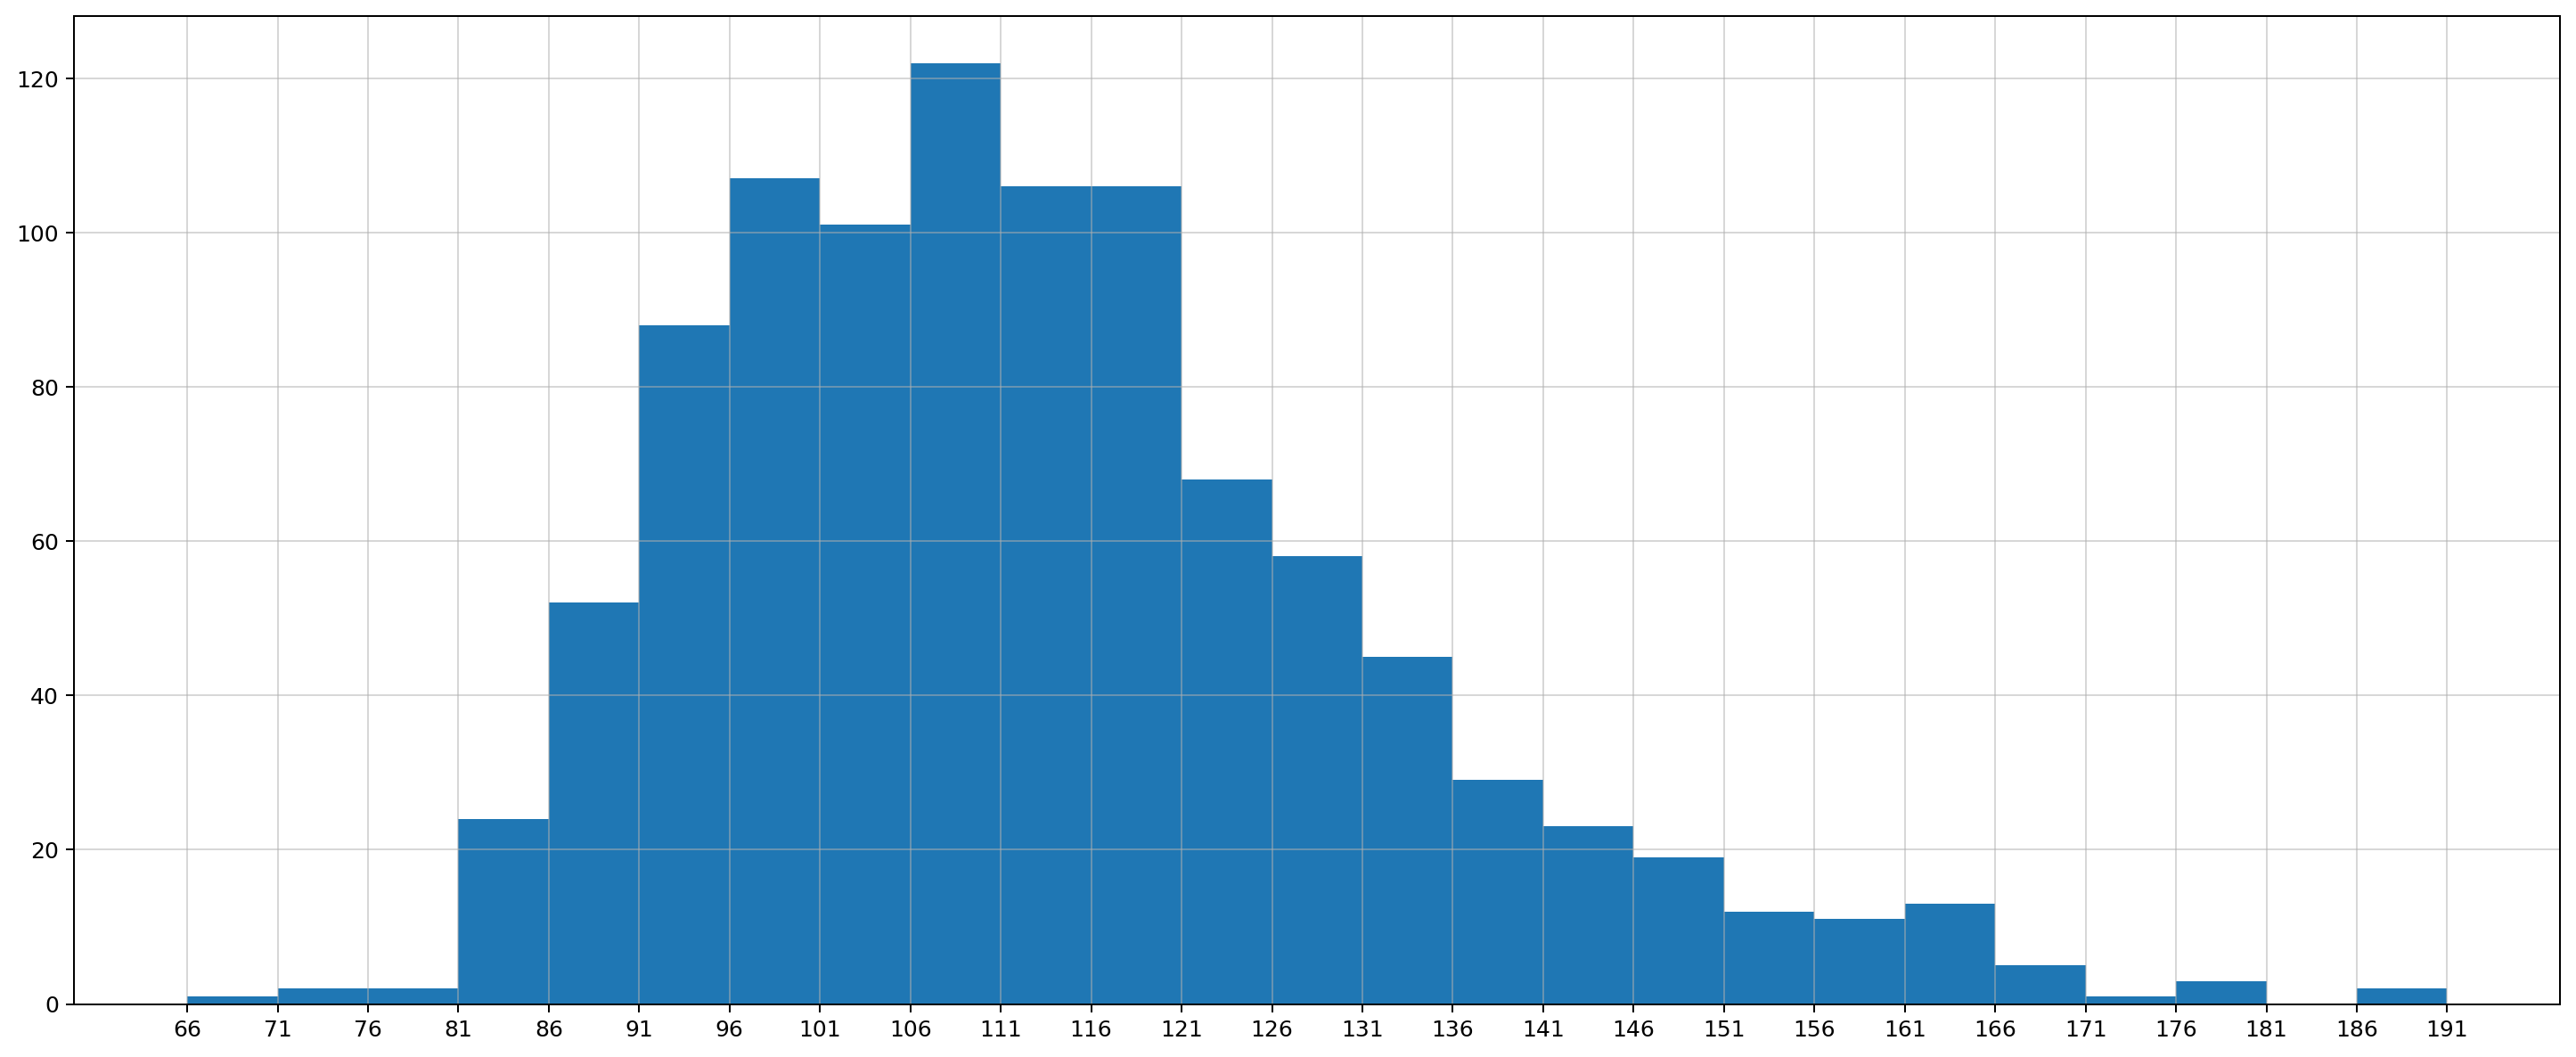

In [31]:
# df["Runtime (Minutes)"].values：取出这一列全部数据，返回numpy ndarray
runtime_data = df["Runtime (Minutes)"].values                   # 这里得到的是一维ndarray数组
max_runtime = runtime_data.max()
min_runtime = runtime_data.min()
print(min_runtime, max_runtime)
print(max_runtime - min_runtime)
# 计算组数，组距为5
num_bin = (max_runtime - min_runtime) // 5

# 设置图形的大小
plt.figure(figsize=(20, 8), dpi=180)

plt.hist(runtime_data, int(num_bin))
plt.grid(alpha=0.5)
plt.xticks(range(min_runtime, max_runtime + 5, 5))

plt.show()

In [32]:
# 电影评分的分布情况，获取平均评分
print(df['Rating'].mean())

# rating,runtime分布情况
rating_data = df['Rating'].values              # 这里得到的是一维ndarray数组
print(rating_data)
print(rating_data.shape)                       # (1000,)
print(type(rating_data))                       # <class 'numpy.ndarray'>

6.723199999999999
[8.1 7.  7.3 7.2 6.2 6.1 8.3 6.4 7.1 7.  7.5 7.8 7.9 7.7 6.4 6.6 8.2 6.7
 8.1 8.  6.7 7.9 6.7 6.5 5.3 6.8 8.3 4.7 6.2 5.9 6.3 7.5 7.1 8.  5.6 7.9
 8.6 7.6 6.9 7.1 6.3 7.5 2.7 7.2 6.3 6.7 7.3 5.6 7.1 3.7 8.1 5.8 5.6 7.2
 9.  7.3 7.2 7.4 7.  7.5 6.7 6.8 6.5 4.1 8.5 7.7 7.4 8.1 7.5 7.2 5.9 7.1
 7.5 6.8 8.1 7.1 8.1 8.3 7.3 5.3 8.8 7.9 8.2 8.1 7.2 7.  6.4 7.8 7.8 7.4
 8.1 7.  8.1 7.1 7.4 7.4 8.6 5.8 6.3 8.5 7.  7.  8.  7.9 7.3 7.7 5.4 6.3
 5.8 7.7 6.3 8.1 6.1 7.7 8.1 5.8 6.2 8.8 7.2 7.4 6.7 6.7 6.  7.4 8.5 7.5
 5.7 6.6 6.4 8.  7.3 6.  6.4 8.5 7.1 7.3 8.1 7.3 8.1 7.1 8.  6.2 7.8 8.2
 8.4 8.1 7.4 7.6 7.6 6.2 6.4 7.2 5.8 7.6 8.1 4.7 7.  7.4 7.5 7.9 6.  7.
 8.  6.1 8.  5.2 6.5 7.3 7.3 6.8 7.9 7.9 5.2 8.  7.5 6.5 7.6 7.  7.4 7.3
 6.7 6.8 7.  5.9 8.  6.  6.3 6.6 7.8 6.3 7.2 5.6 8.1 5.8 8.2 6.9 6.3 8.1
 8.1 6.3 7.9 6.5 7.3 7.9 5.7 7.8 7.5 7.5 6.8 6.7 6.1 5.3 7.1 5.8 7.  5.5
 7.8 5.7 6.1 7.7 6.7 7.1 6.9 7.8 7.  7.  7.1 6.4 7.  4.8 8.2 5.2 7.8 7.4
 6.1 8.  6.8 3.9 8.1 5.9 7.6 8.2 5

In [33]:
max_rating = rating_data.max()
min_rating = rating_data.min()
print(min_rating, max_rating)                 # 最大值、最小值电影评分

1.9 9.0


组数为[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]


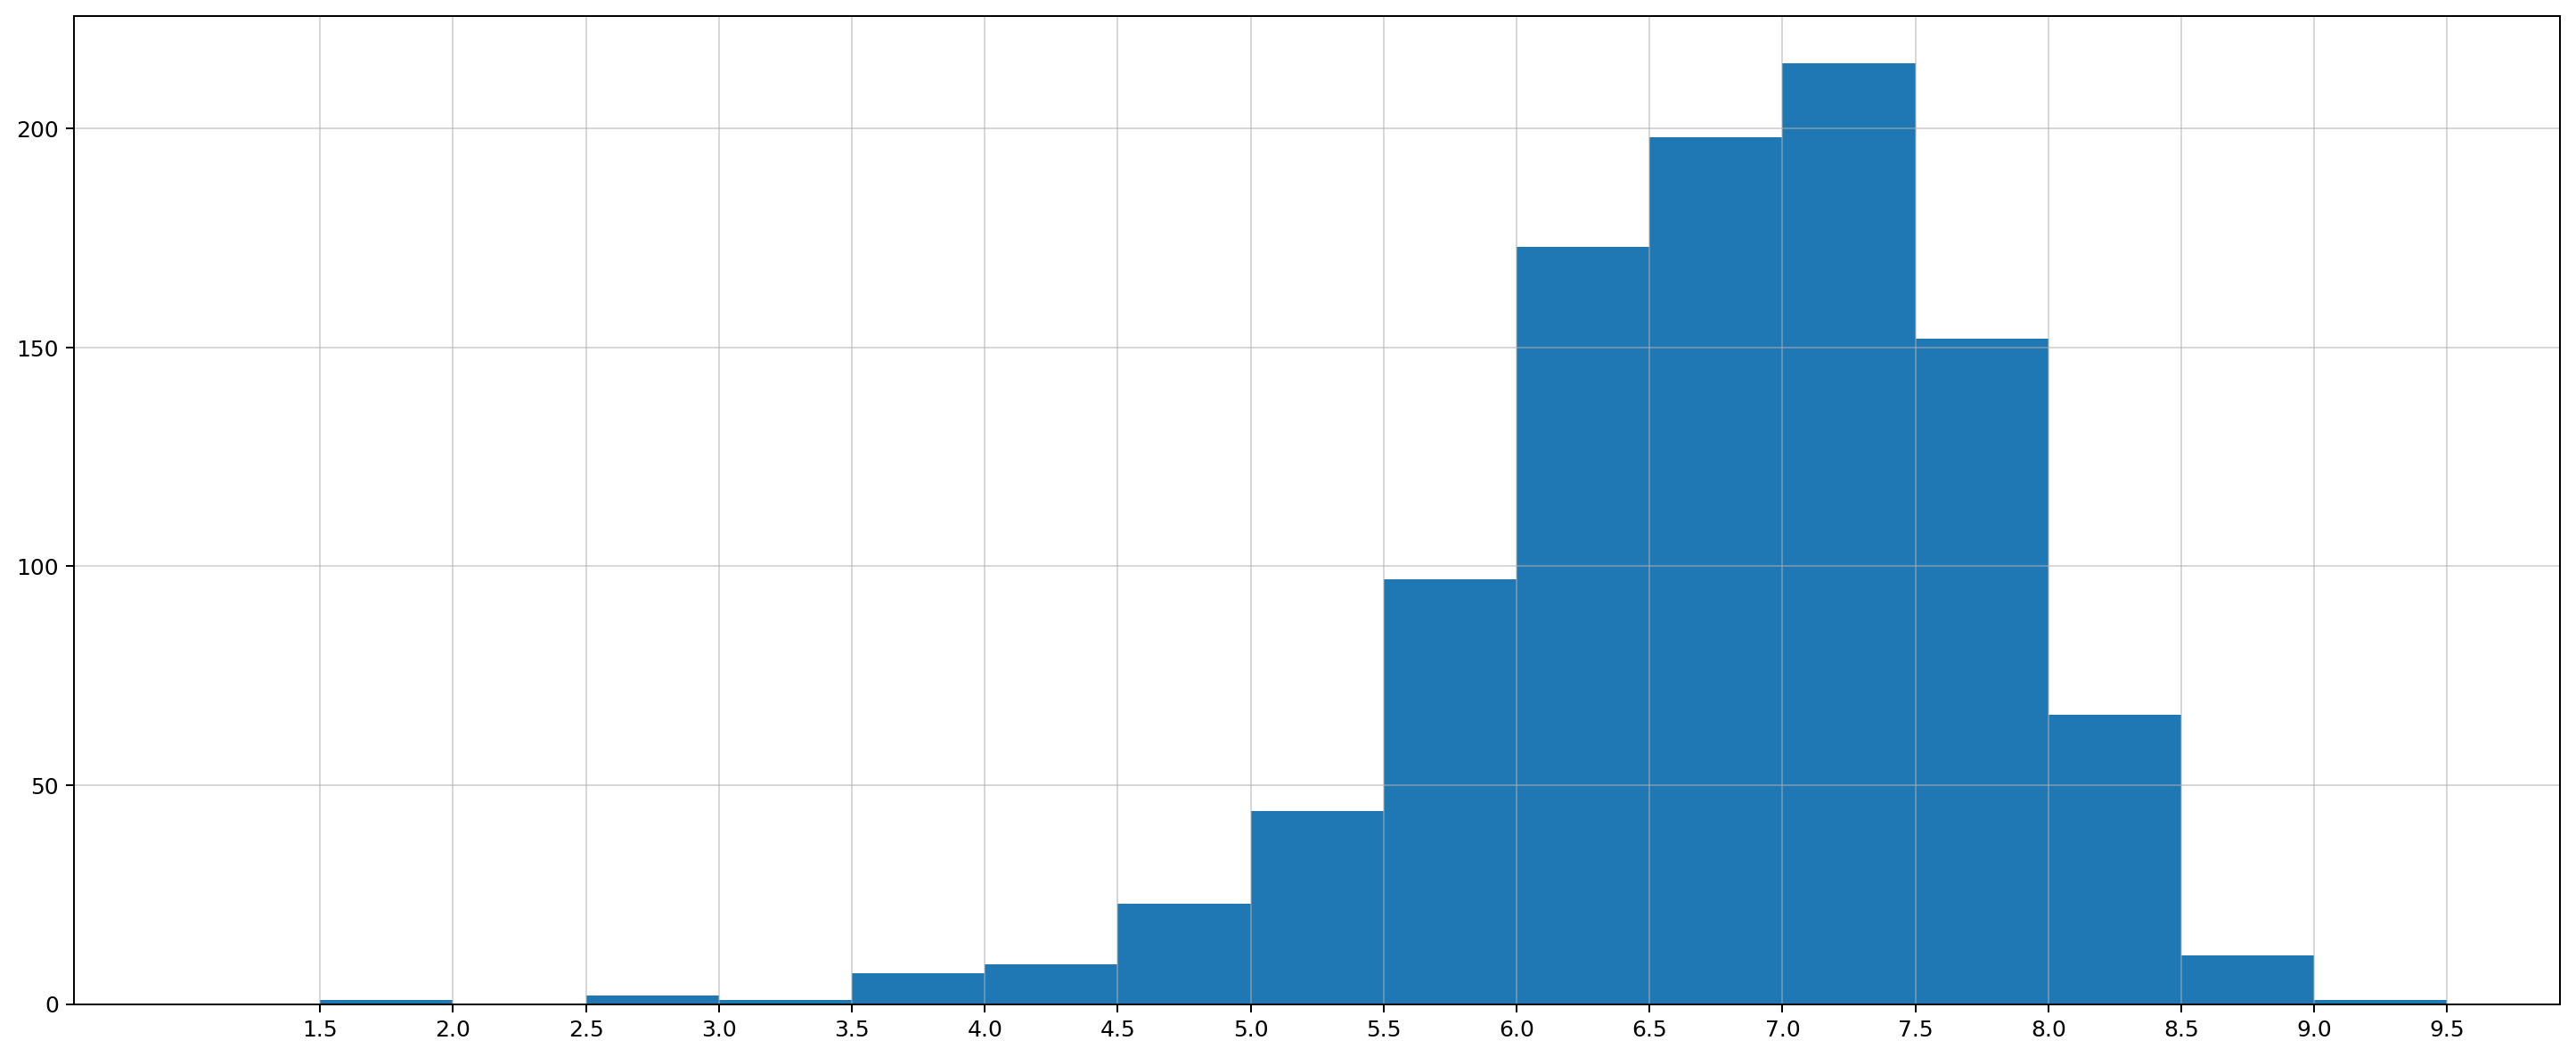

In [38]:
beautify_min = np.floor(min_rating)
beautify_max = np.ceil(max_rating)
# print(f'最大评分减去最小评分{max_rating - min_rating}')
# //：向下取整，往数字更小的数取整
num_bin = np.arange(beautify_min, beautify_max + 1, 0.5)
print(f'组数为{num_bin}')

plt.figure(figsize=(20, 8), dpi=180)
# 第二个bins参数必须为int、sequence或str，bins代表划分为多少单元
# plt.hist的bins参数接收两种数据类型：整数（int型）：代表分组数量，函数自动均分区间；一维数组：代表自定义bin边界
plt.hist(rating_data, num_bin)
plt.grid(alpha=0.5)
plt.xticks(np.arange(1.5, 10, 0.5))
plt.show()

# 8.3.3 导演要拍什么题材电影

In [39]:
# 自定义查看前几条数据
print(df['Genre'].head(3))

0     Action,Adventure,Sci-Fi
1    Adventure,Mystery,Sci-Fi
2             Horror,Thriller
Name: Genre, dtype: str


In [49]:
# .str.split(',')：pandas专用批量操作，Series的字符串访问器，以逗号（,）分割每个单元格里的字符串，得到列表Series（每个单元格内）
temp_list0 = df['Genre'].str.split(',')                     # 这里是Series数据类型
print(temp_list0)
print(type(temp_list0))                                     # <class 'pandas.Series'>
temp_list = temp_list0.tolist()                             # 将外层Series数据类型转换为list，此时数据为双层嵌套列表
print(temp_list)

0       [Action, Adventure, Sci-Fi]
1      [Adventure, Mystery, Sci-Fi]
2                [Horror, Thriller]
3       [Animation, Comedy, Family]
4      [Action, Adventure, Fantasy]
                   ...             
995         [Crime, Drama, Mystery]
996                        [Horror]
997         [Drama, Music, Romance]
998             [Adventure, Comedy]
999       [Comedy, Family, Fantasy]
Name: Genre, Length: 1000, dtype: object
<class 'pandas.Series'>
[['Action', 'Adventure', 'Sci-Fi'], ['Adventure', 'Mystery', 'Sci-Fi'], ['Horror', 'Thriller'], ['Animation', 'Comedy', 'Family'], ['Action', 'Adventure', 'Fantasy'], ['Action', 'Adventure', 'Fantasy'], ['Comedy', 'Drama', 'Music'], ['Comedy'], ['Action', 'Adventure', 'Biography'], ['Adventure', 'Drama', 'Romance'], ['Adventure', 'Family', 'Fantasy'], ['Biography', 'Drama', 'History'], ['Action', 'Adventure', 'Sci-Fi'], ['Animation', 'Adventure', 'Comedy'], ['Action', 'Comedy', 'Drama'], ['Animation', 'Adventure', 'Comedy'], ['Biogra

In [51]:
# 二维变一维；set()去重，集合自动剔除重复元素，缺点是集合是无序的，顺序会打乱
genre_list = list(set([i for j in temp_list for i in j]))
print(len(genre_list))
zeros_df = pd.DataFrame(np.zeros((df.shape[0], len(genre_list))), columns=genre_list)
print(zeros_df)

20
     Action  Comedy  Music  Sport  Musical  Fantasy  War  Sci-Fi  Thriller  \
0       0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
1       0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
2       0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
3       0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
4       0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
..      ...     ...    ...    ...      ...      ...  ...     ...       ...   
995     0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
996     0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
997     0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
998     0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   
999     0.0     0.0    0.0    0.0      0.0      0.0  0.0     0.0       0.0   

     Romance  Family  Mystery  Horror  Adventure  Crime  Wes

In [52]:
# 给每个电影出现分类的位置赋值1，one-hot是独热码
for i in range(df.shape[0]):
    # temp_list是一个二维列表，temp_list[i]是一个一维列表
    zeros_df.loc[i, temp_list[i]] = 1
    
zeros_df.head(3)

,Action,Comedy,Music,Sport,Musical,Fantasy,War,Sci-Fi,Thriller,Romance,Family,Mystery,Horror,Adventure,Crime,Western,Drama,History,Biography,Animation
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
genre_count = zeros_df.sum(axis=0)
print(genre_count)

Action       303.0
Comedy       279.0
Music         16.0
Sport         18.0
Musical        5.0
Fantasy      101.0
War           13.0
Sci-Fi       120.0
Thriller     195.0
Romance      141.0
Family        51.0
Mystery      106.0
Horror       119.0
Adventure    259.0
Crime        150.0
Western        7.0
Drama        513.0
History       29.0
Biography     81.0
Animation     49.0
dtype: float64


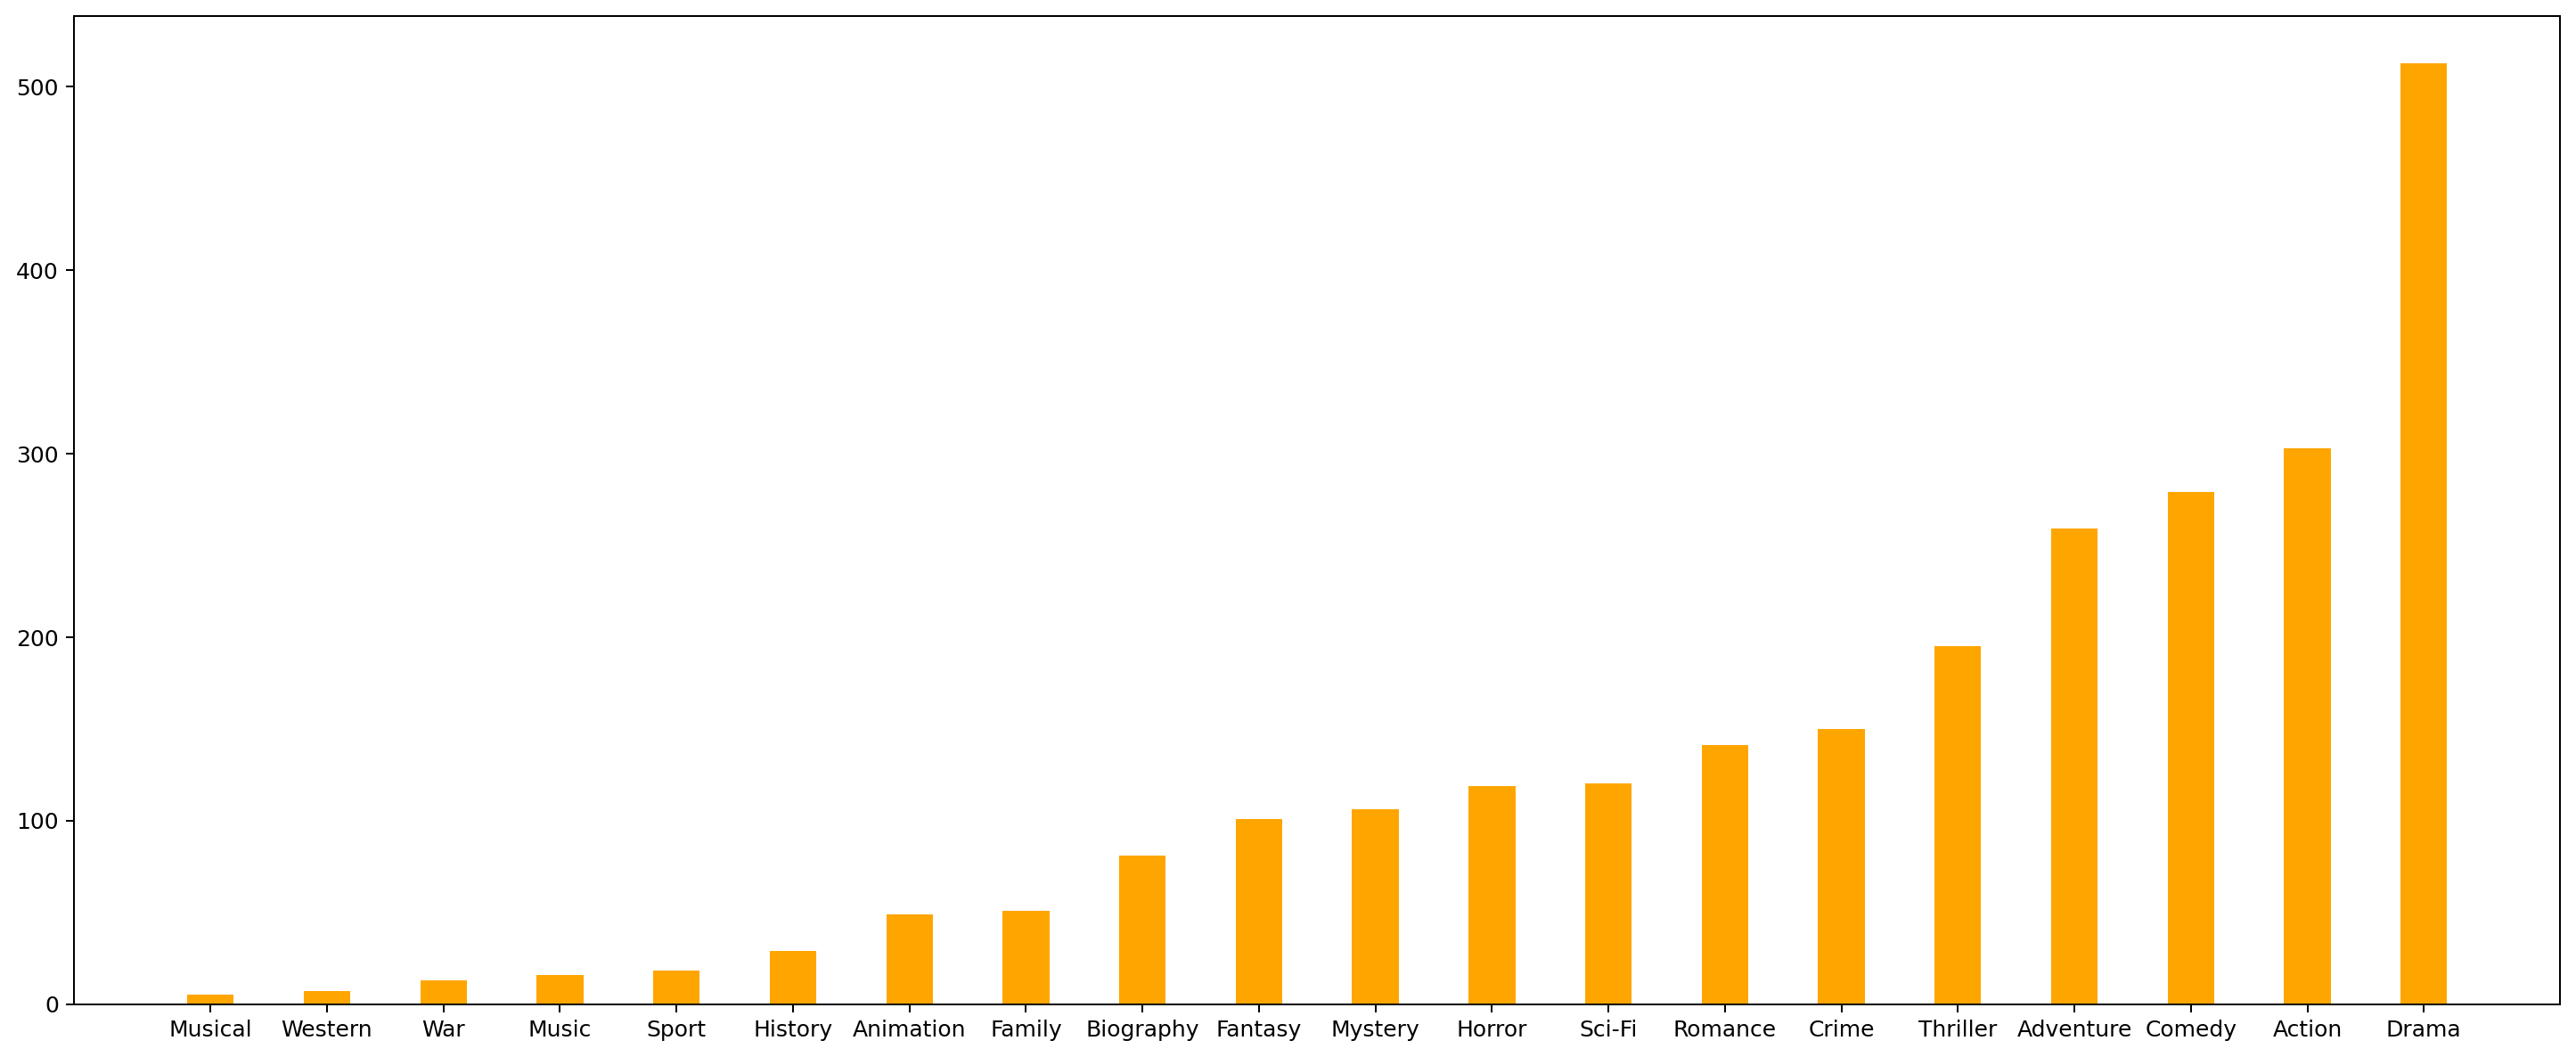

In [59]:
# 按值排序，ascending默认升序，False是降序
genre_count = genre_count.sort_values(ascending=True)
_x = genre_count.index
_y = genre_count.values

plt.figure(figsize=(20, 8), dpi=180)
plt.bar(range(len(_x)), _y, width=0.4, color='orange')
plt.xticks(range(len(_x)), _x)
plt.show()